# Actividad 12 – Detección de esquinas

**Objetivo**: usar Harris Corner Detection.

En esta actividad vamos a:
1. Cargar una imagen
2. Convertir a escala de grises y float32
3. Aplicar cornerHarris
4. Marcar esquinas en rojo
5. Comparar con la imagen original

## 1. Importar librerías necesarias

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar imagen

Cambia la ruta por la ubicación de tu imagen.

✓ Imagen cargada correctamente


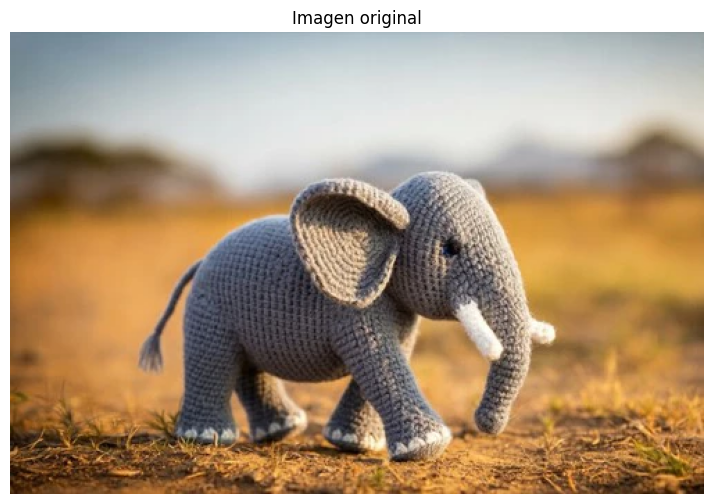

In [2]:
# Cargar la imagen
imagen = cv2.imread('imagen.webp')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    
    # Mostrar la imagen original
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title('Imagen original')
    plt.show()

## 3. Convertir a escala de grises y float32

El algoritmo Harris requiere que la imagen esté en escala de grises y formato float32.

✓ Imagen convertida a escala de grises y float32
  Tipo de dato original: uint8
  Tipo de dato gris:     uint8
  Tipo de dato float32:  float32
  Dimensiones:           (333, 500)


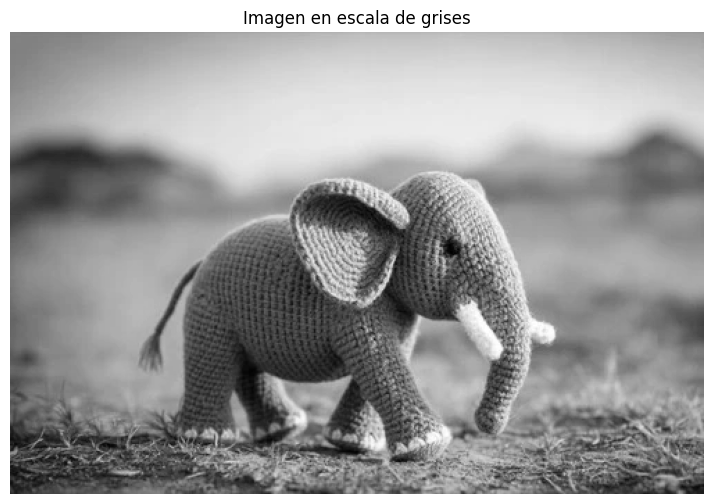

In [3]:
# Convertir a escala de grises
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

# Convertir a float32 (requerido por cornerHarris)
imagen_float32 = np.float32(imagen_gris)

print("✓ Imagen convertida a escala de grises y float32")
print(f"  Tipo de dato original: {imagen.dtype}")
print(f"  Tipo de dato gris:     {imagen_gris.dtype}")
print(f"  Tipo de dato float32:  {imagen_float32.dtype}")
print(f"  Dimensiones:           {imagen_float32.shape}")

plt.figure(figsize=(10, 6))
plt.imshow(imagen_gris, cmap='gray')
plt.title('Imagen en escala de grises')
plt.axis('off')
plt.show()

## 4. Aplicar cornerHarris

Harris Corner Detection identifica puntos en la imagen donde hay cambios significativos de intensidad en múltiples direcciones.

✓ Harris Corner Detection aplicado
  Block size: 2
  Kernel size: 3
  Parámetro k: 0.04
  Resultado shape: (333, 500)
  Valores mín/máx: -22240936.000000 / 20836262.000000


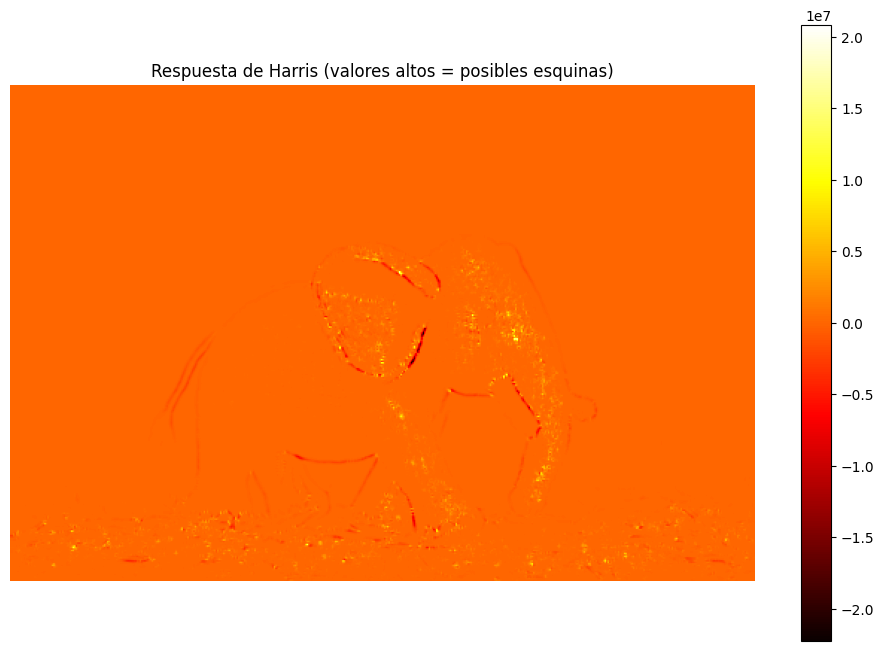

In [4]:
# Aplicar Harris Corner Detection
# Parámetros:
# - imagen_float32: imagen en escala de grises float32
# - blockSize: tamaño del vecindario considerado (2 es común)
# - ksize: tamaño del kernel Sobel (debe ser impar)
# - k: parámetro libre de Harris (típicamente entre 0.04 - 0.06)

blockSize = 2
ksize = 3
k = 0.04

esquinas = cv2.cornerHarris(imagen_float32, blockSize, ksize, k)

print(f"✓ Harris Corner Detection aplicado")
print(f"  Block size: {blockSize}")
print(f"  Kernel size: {ksize}")
print(f"  Parámetro k: {k}")
print(f"  Resultado shape: {esquinas.shape}")
print(f"  Valores mín/máx: {esquinas.min():.6f} / {esquinas.max():.6f}")

# Visualizar el mapa de respuesta de Harris
plt.figure(figsize=(12, 8))
plt.imshow(esquinas, cmap='hot')
plt.colorbar()
plt.title('Respuesta de Harris (valores altos = posibles esquinas)')
plt.axis('off')
plt.show()

## 5. Marcar esquinas en rojo

Dilatamos el resultado para hacerlo más visible y marcamos las esquinas detectadas.

In [5]:
# Dilatar el resultado para mejorar la visualización
esquinas = cv2.dilate(esquinas, None)

# Crear una copia de la imagen para marcar las esquinas
imagen_con_esquinas = imagen_rgb.copy()

# Umbralizar: marcar en rojo los píxeles donde la respuesta es mayor que un porcentaje del máximo
# Típicamente se usa entre 0.01 y 0.1 del valor máximo
umbral = 0.01 * esquinas.max()

# Marcar esquinas en rojo
imagen_con_esquinas[esquinas > umbral] = [255, 0, 0]  # Rojo en RGB

# Contar esquinas detectadas
num_esquinas = np.sum(esquinas > umbral)

print(f"✓ Esquinas marcadas en rojo")
print(f"  Umbral usado: {umbral:.6f}")
print(f"  Esquinas detectadas: {num_esquinas}")
print(f"  Porcentaje del máximo: 1%")

✓ Esquinas marcadas en rojo
  Umbral usado: 208362.620000
  Esquinas detectadas: 24662
  Porcentaje del máximo: 1%


## 6. Comparar con la imagen original

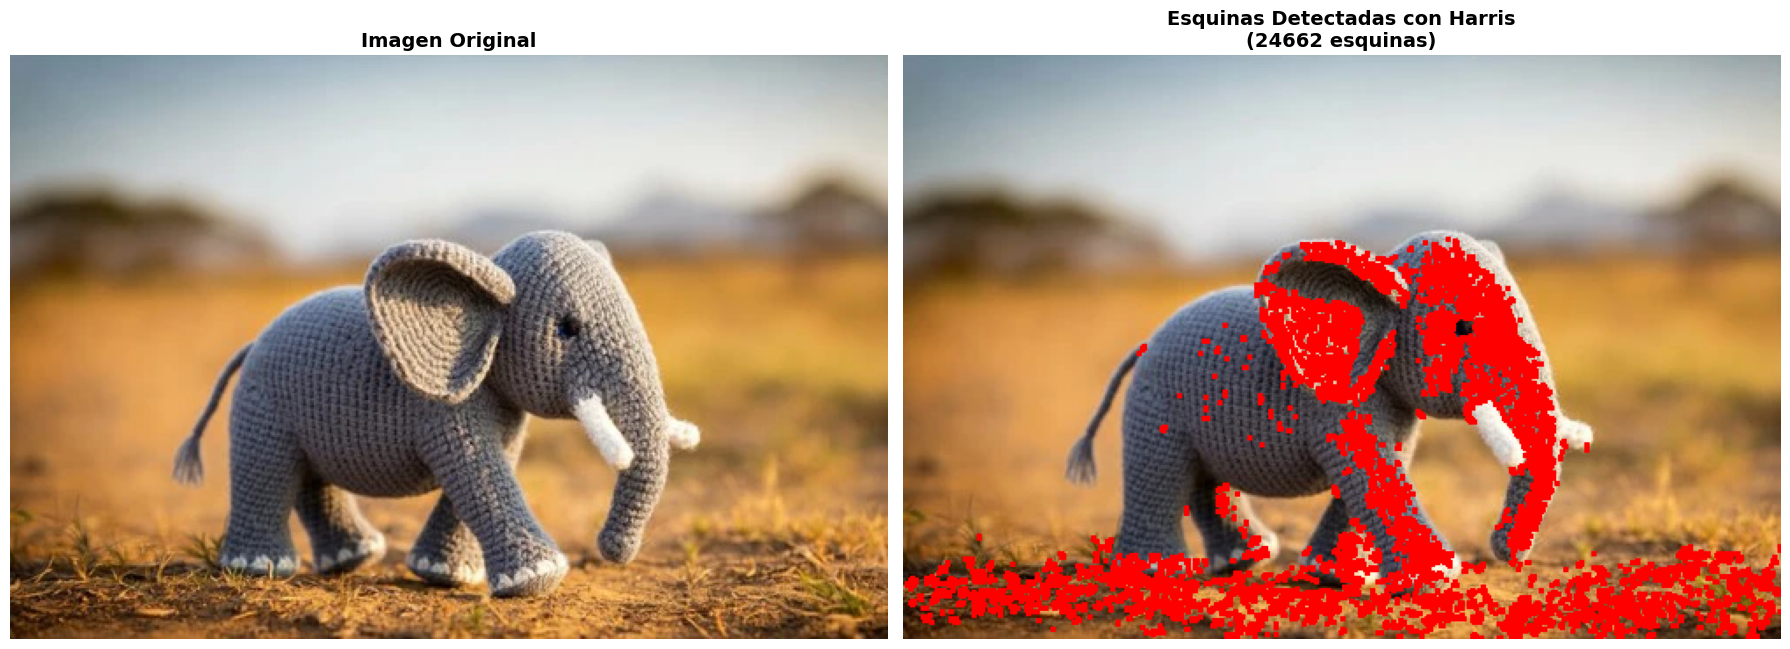


INFORMACIÓN SOBRE HARRIS CORNER DETECTION
El algoritmo Harris detecta esquinas buscando regiones donde
hay cambios significativos de intensidad en múltiples direcciones.

Parámetros clave:
- blockSize: tamaño del vecindario analizado
- ksize: tamaño del operador Sobel para gradientes
- k: sensibilidad del detector (mayor k = menos esquinas)

Ajusta el umbral (actualmente 1% del máximo) para controlar
la cantidad de esquinas detectadas.


In [6]:
# Mostrar comparación lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Imagen original
axes[0].imshow(imagen_rgb)
axes[0].set_title('Imagen Original', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Imagen con esquinas marcadas
axes[1].imshow(imagen_con_esquinas)
axes[1].set_title(f'Esquinas Detectadas con Harris\n({num_esquinas} esquinas)', 
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Información adicional
print("\n" + "="*60)
print("INFORMACIÓN SOBRE HARRIS CORNER DETECTION")
print("="*60)
print("El algoritmo Harris detecta esquinas buscando regiones donde")
print("hay cambios significativos de intensidad en múltiples direcciones.")
print("\nParámetros clave:")
print("- blockSize: tamaño del vecindario analizado")
print("- ksize: tamaño del operador Sobel para gradientes")
print("- k: sensibilidad del detector (mayor k = menos esquinas)")
print("\nAjusta el umbral (actualmente 1% del máximo) para controlar")
print("la cantidad de esquinas detectadas.")
print("="*60)